# Lab 7.2 — RAG over Government Documents

*Chapter 7 — Building with LLMs: APIs, RAG, and Agents · 40 minutes · JupyterLab + OpenAI API (local embedding fallback offline)*

Four agency policy documents and a question whose answer is buried in one of
them. This is the pattern behind every "chat with our documents" pilot:
retrieve the right chunks, ground the answer in them, force citations — and
verify those citations instead of trusting them.

Cells marked `# YOUR CODE` are yours to write. Every cell runs as shipped: a
reference implementation and labelled canned answers keep the lab moving, and
embeddings fall back to a deterministic local hasher when there is no key.

## Objectives

By the end of this lab, you will:

- Build a working retrieval pipeline over real policy documents.
- Force citations and verify them.
- Diagnose retrieval failure rather than blaming the model.

## Setup

- **Corpus (synthetic training documents, modelled on public federal practice):**
  - `data/corpus/ai_acceptable_use_policy.md`
  - `data/corpus/data_governance_standard.md`
  - `data/corpus/foia_processing_guidance.md`
  - `data/corpus/records_retention_policy.md`
- **Key:** `OPENAI_API_KEY` from the environment / course `.env` (never printed).
  Without it, chunk embeddings use the deterministic local fallback in
  `lab_common` and generation returns labelled canned answers — retrieval still
  works end to end.
- **Helpers:** `lab_common` provides `load_corpus`, `embed_texts`,
  `cosine_topk`, `get_client`, `online`, `CHAT_MODEL`, `EMBED_MODEL`.

In [1]:
# API key: uses OPENAI_API_KEY from the environment (classroom VM); when run on
# the author's machine it falls back to the course .env file found by walking up
# from the notebook directory. The key is never printed.
import os, pathlib
def _load_api_key():
    if os.getenv("OPENAI_API_KEY") is not None:
        return  # environment wins — an explicitly empty value forces offline mode
    for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        env = p / ".env"
        if env.is_file():
            for line in env.read_text().splitlines():
                k, _, v = line.partition("=")
                if k.strip() == "OPENAI_API_KEY" and v.strip():
                    os.environ["OPENAI_API_KEY"] = v.strip()
                    return
_load_api_key()
if not os.getenv("OPENAI_API_KEY"):
    print("OPENAI_API_KEY not set - ask your instructor, or the AI steps will be skipped/mocked.")

OPENAI_API_KEY not set - ask your instructor, or the AI steps will be skipped/mocked.


In [2]:
import re
import textwrap
import matplotlib.pyplot as plt
from lab_common import (load_corpus, embed_texts, cosine_topk,
                        get_client, online, CHAT_MODEL, EMBED_MODEL)

EMBEDDER_USED = {"name": "not yet run"}

def embed(texts):
    """Embed via lab_common; if the API call itself fails (quota, network),
    say so and use the deterministic local fallback instead of crashing."""
    try:
        vecs = embed_texts(texts)
        EMBEDDER_USED["name"] = (f"OpenAI {EMBED_MODEL}" if online()
                                 else "local hashing fallback (offline)")
        return vecs
    except Exception as e:
        print(f"({type(e).__name__} — embedding API failed; using the local fallback)")
        EMBEDDER_USED["name"] = "local hashing fallback (API call failed)"
        from lab_common import _local_embed
        return [_local_embed(t) for t in texts]

The pipeline you are about to build — keep this picture in mind; every step
below is one box of it:

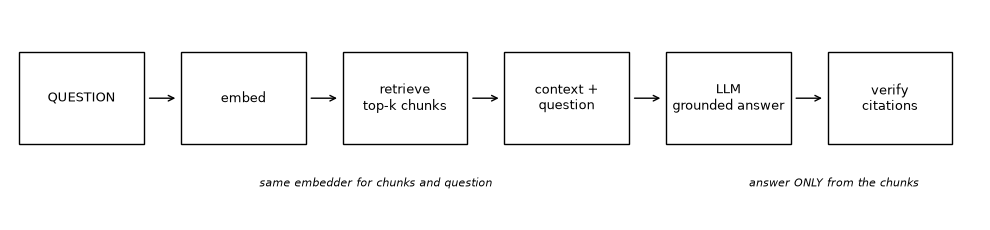

In [3]:
fig, ax = plt.subplots(figsize=(10, 2.4))
boxes = ["QUESTION", "embed", "retrieve\ntop-k chunks", "context +\nquestion", "LLM\ngrounded answer", "verify\ncitations"]
for i, label in enumerate(boxes):
    ax.add_patch(plt.Rectangle((i * 1.75, 0.3), 1.35, 0.55, fill=False))
    ax.text(i * 1.75 + 0.675, 0.575, label, ha="center", va="center", fontsize=9)
    if i < len(boxes) - 1:
        ax.annotate("", xy=(i * 1.75 + 1.72, 0.575), xytext=(i * 1.75 + 1.38, 0.575),
                    arrowprops=dict(arrowstyle="->"))
ax.text(2.6, 0.05, "same embedder for chunks and question", fontsize=8, style="italic")
ax.text(7.9, 0.05, "answer ONLY from the chunks", fontsize=8, style="italic")
ax.set_xlim(-0.1, 10.4); ax.set_ylim(-0.15, 1.1); ax.axis("off")
plt.tight_layout(); plt.show()

## Steps

1. Run the load + chunk cells. ✓ You see *"N documents → M chunks."*
2. Run the embed cell. ✓ *"embedded M chunks."*
3. Complete `retrieve()` — embed the question and return the top-k chunks.
   ✓ The retrieved chunks are about the question.
4. Complete the grounding instruction so the model answers only from the
   context and cites the source file. ✓ The grounded answer carries
   `[filename]` citations.
5. Run the ungrounded comparison. ✓ You can see the difference.

Run the Setup cells above first (loader, imports, diagram).

### Step 1 — Load the four documents and chunk them (5 min)

Chunk = one paragraph (blank-line separated), dropping tiny fragments. Print
the chunk count **and** the sizes — chunk size is the knob you turn in the
stretch section.

In [4]:
docs = load_corpus()

def chunk_docs(docs, min_len=60):
    """One chunk per paragraph (blank-line separated), dropping tiny fragments."""
    out = []
    for d in docs:
        for para in [p.strip() for p in d["text"].split("\n\n") if len(p.strip()) > min_len]:
            out.append({"source": d["source"], "text": para})
    return out

chunks = chunk_docs(docs)
sizes = sorted(len(c["text"]) for c in chunks)
print(f"{len(docs)} documents → {len(chunks)} chunks")
print(f"chunk sizes (chars): min {sizes[0]}, median {sizes[len(sizes) // 2]}, max {sizes[-1]}")
for d in docs:
    print(f"  {d['source']}: {sum(1 for c in chunks if c['source'] == d['source'])} chunks")

4 documents → 26 chunks
chunk sizes (chars): min 111, median 249, max 404
  ai_acceptable_use_policy.md: 6 chunks
  data_governance_standard.md: 7 chunks
  foia_processing_guidance.md: 7 chunks
  records_retention_policy.md: 6 chunks


### Step 2 — Embed the chunks (4 min)

One vector per chunk. With a key this uses OpenAI embeddings; offline it falls
back to a deterministic local hasher (dim 256) — good enough to rank four
small documents, which is why the lab works with no network.

In [5]:
chunk_vecs = embed([c["text"] for c in chunks])
print(f"embedded {len(chunk_vecs)} chunks, dim={len(chunk_vecs[0])}")
print("embedder:", EMBEDDER_USED["name"])

embedded 26 chunks, dim=256
embedder: local hashing fallback (offline)


### Step 3 — Retrieve the top 3 chunks and inspect them (8 min)

Complete `retrieve`: embed the question with the **same** embedder, rank chunks
by cosine similarity, return the top-k `(chunk, score)` pairs. Read the chunks
*before* generating — is the answer actually in them?

`embed()` and `cosine_topk()` are already imported for you.

In [6]:
QUESTION = "How long are program case files kept before they are destroyed?"

RETRIEVE_NOTICE = []          # so the notice prints once, not once per call

def retrieve(question, k=3):
    """Return the k chunks most similar to `question`, as (chunk, score) pairs."""
    ranked = None
    # YOUR CODE: embed the question with embed([...])[0], rank it against
    # chunk_vecs with cosine_topk(query_vec, doc_vecs, k), and build
    # ranked = [(chunks[i], score), ...] in rank order.
    if ranked is None:
        qv = embed([question])[0]
        ranked = [(chunks[i], score) for i, score in cosine_topk(qv, chunk_vecs, k)]
        if not RETRIEVE_NOTICE:
            print("(reference retrieve() used — write yours above, then re-run)\n")
            RETRIEVE_NOTICE.append(1)
    return ranked

retrieved = retrieve(QUESTION, k=3)
for c, score in retrieved:
    print(f"[{score:.3f}] {c['source']}")
    print(textwrap.fill(textwrap.shorten(c["text"], 220), 100), "\n")

(reference retrieve() used — write yours above, then re-run)

[0.500] records_retention_policy.md
This policy establishes how long agency records are kept and when they are destroyed or transferred
to the National Archives. It implements the agency's records schedule approved by NARA. 

[0.466] records_retention_policy.md
- **Routine administrative correspondence** is retained for 3 years, then destroyed. - **Program
case files** are retained for 7 years after the case is closed. - **Financial and procurement
records** are retained [...] 

[0.429] records_retention_policy.md
Records that have met their retention period are destroyed using methods appropriate to their
sensitivity. Records containing personally identifiable information are shredded or securely wiped.
A destruction log [...] 



### Step 4 — Generate grounded, with citations and quotes (10 min)

The system prompt does the work. Write `GROUNDING_SYSTEM` so the model:

- answers **only** from the provided context,
- cites the source file in `[brackets]` after every fact,
- quotes the exact sentence it relied on,
- and says so plainly when the context does not contain the answer.

That last clause is the one people leave out, and it is the one that stops the
pipeline inventing an answer.

In [7]:
CANNED_GROUNDED = (
    "Program case files are kept for 7 years after the case is closed, then "
    "destroyed [records_retention_policy.md]. The policy states: \"Program case "
    "files are retained for 7 years after the case is closed.\" Note the contrast "
    "with routine administrative correspondence (3 years) in the same file.")
CANNED_ABSENT = ("The provided documents do not say anything about an AI training "
                 "budget for fiscal year 2027. No citation is possible.")

def _canned_grounded(question):
    # the canned stand-in knows two questions: the retention one and the absent one
    return CANNED_ABSENT if "budget" in question.lower() else CANNED_GROUNDED

GROUNDING_SYSTEM = None
# YOUR CODE: write the grounding instruction. It must pin the model to the
# context, require a [filename] citation and an exact quote per fact, and force
# an explicit "not in the context" when the answer is absent.
if GROUNDING_SYSTEM is None:
    GROUNDING_SYSTEM = (
        "Answer ONLY from the provided context. After every fact, cite the source "
        "file in [brackets] and quote the exact sentence you relied on. If the "
        "context does not contain the answer, say so — do not use outside knowledge.")
    print("(reference grounding instruction used — write yours above, then re-run)\n")

def grounded_answer(question, retrieved):
    client = get_client()
    context = "\n\n".join(f"[{c['source']}] {c['text']}" for c, _ in retrieved)
    if client is None:
        print("(offline) canned grounded reply:\n")
        return _canned_grounded(question)
    try:
        resp = client.chat.completions.create(
            model=CHAT_MODEL,
            messages=[
                {"role": "system", "content": GROUNDING_SYSTEM},
                {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"},
            ])
        return resp.choices[0].message.content
    except Exception as e:
        print(f"({type(e).__name__} — call failed; canned grounded reply:)\n")
        return _canned_grounded(question)

answer = grounded_answer(QUESTION, retrieved)
print(answer)

(reference grounding instruction used — write yours above, then re-run)

(offline) canned grounded reply:

Program case files are kept for 7 years after the case is closed, then destroyed [records_retention_policy.md]. The policy states: "Program case files are retained for 7 years after the case is closed." Note the contrast with routine administrative correspondence (3 years) in the same file.


### Step 5 — Run the ungrounded comparison (8 min)

Same question, no context, no retrieval. Put the two answers side by side and
read them as a constituent would: one cites a file you can open, the other
sounds equally confident and is wrong about the period.

In [8]:
CANNED_UNGROUNDED = (
    "Program case files are generally kept for 3 years after the case is closed, "
    "after which they are destroyed. Some agencies keep them longer if litigation "
    "is expected. (Typical ungrounded answer: confident, plausible — and, for this "
    "corpus, wrong about the period.)")

def ask_plain(question):
    client = get_client()
    if client is None:
        return CANNED_UNGROUNDED
    try:
        resp = client.chat.completions.create(
            model=CHAT_MODEL, messages=[{"role": "user", "content": question}])
        return resp.choices[0].message.content
    except Exception as e:
        print(f"({type(e).__name__} — call failed; canned ungrounded reply)")
        return CANNED_UNGROUNDED

ungrounded = ask_plain(QUESTION)

print("=" * 78)
print("GROUNDED (retrieval + citations):\n")
print(textwrap.fill(answer, 78))
print("\n" + "=" * 78)
print("UNGROUNDED (no retrieval, answered from memory):\n")
print(textwrap.fill(ungrounded, 78))
print("=" * 78)
print("\n✓ Which one would you put in front of a constituent, and why?")

GROUNDED (retrieval + citations):

Program case files are kept for 7 years after the case is closed, then
destroyed [records_retention_policy.md]. The policy states: "Program case
files are retained for 7 years after the case is closed." Note the contrast
with routine administrative correspondence (3 years) in the same file.

UNGROUNDED (no retrieval, answered from memory):

Program case files are generally kept for 3 years after the case is closed,
after which they are destroyed. Some agencies keep them longer if litigation
is expected. (Typical ungrounded answer: confident, plausible — and, for this
corpus, wrong about the period.)

✓ Which one would you put in front of a constituent, and why?


## Stretch (not timed)

The workbook page ends at Step 5. Everything below is optional.

### Stretch A — Check every citation against the source file

A citation is a claim, not a fact. The checker below verifies (a) every
`[file.md]` tag names a real corpus file and (b) every quoted sentence
actually appears in the corpus. Run it on your grounded answer.

In [9]:
def _plain(s):
    """Strip markdown emphasis so quotes match the raw files."""
    return re.sub(r"[*_#`]", "", s)

def check_citations(answer, docs):
    files = {d["source"]: d["text"] for d in docs}
    for tag in sorted(set(re.findall(r"\[([\w.\-]+\.md)\]", answer))):
        print(f"source [{tag}]: {'exists' if tag in files else 'MISSING — fabricated citation'}")
    quotes = re.findall(r'"([^"]{20,})"', answer)
    if not quotes:
        print("no quoted sentences found — demand quotes in the system prompt")
    for q in quotes:
        hits = [name for name, text in files.items() if _plain(q).strip() in _plain(text)]
        print(f"quote \"{q[:60]}...\":",
              "verified in " + ", ".join(hits) if hits else "NOT FOUND — possible fabrication")

check_citations(answer, docs)

source [records_retention_policy.md]: exists
quote "Program case files are retained for 7 years after the case i...": verified in records_retention_policy.md


### Stretch B — Confirm or refute one DO NOW 7.D prediction

Take one failure you predicted in DO NOW 7.D and test it. The question below
is designed to fail cleanly: the answer is **absent from all four documents**.
A well-grounded pipeline should say so instead of improvising.

In [10]:
HARD_QUESTION = "What is the agency's AI training budget for fiscal year 2027?"

retrieved_hard = retrieve(HARD_QUESTION, k=3)
print("top chunks for an unanswerable question (note the low scores):")
for c, score in retrieved_hard:
    print(f"  [{score:.3f}] {c['source']}: {textwrap.shorten(c['text'], 80)}")

print()
print(grounded_answer(HARD_QUESTION, retrieved_hard))
print("\nMy 7.D prediction confirmed/refuted (write here): ...")

top chunks for an unanswerable question (note the low scores):
  [0.445] ai_acceptable_use_policy.md: - **Public data** (for example, published reports and open data from [...]
  [0.444] records_retention_policy.md: Electronic records are subject to the same retention periods as their [...]
  [0.442] data_governance_standard.md: Programs collect only the data needed for their mission and retain it only [...]

(offline) canned grounded reply:

The provided documents do not say anything about an AI training budget for fiscal year 2027. No citation is possible.

My 7.D prediction confirmed/refuted (write here): ...


### Stretch C — Change the chunk size and re-run the failing question

Paragraph chunks are one choice. Fixed-width windows are another. Re-chunk at
~450 characters, re-embed, and re-run your failing question — did retrieval
change? When would fixed windows beat paragraphs?

In [11]:
def chunk_by_size(docs, width=450):
    """Fixed-width character windows instead of whole paragraphs."""
    out = []
    for d in docs:
        flat = " ".join(d["text"].split())
        for i in range(0, len(flat), width):
            piece = flat[i:i + width]
            if len(piece) > 60:
                out.append({"source": d["source"], "text": piece})
    return out

chunks2 = chunk_by_size(docs)
vecs2 = embed([c["text"] for c in chunks2])
print(f"fixed-width: {len(chunks2)} chunks (was {len(chunks)} paragraphs)")
qv = embed([QUESTION])[0]
for i, score in cosine_topk(qv, vecs2, 3):
    print(f"[{score:.3f}] {chunks2[i]['source']}: {textwrap.shorten(chunks2[i]['text'], 90)}")

fixed-width: 17 chunks (was 26 paragraphs)
[0.476] records_retention_policy.md: retained for 3 years, then destroyed. - **Program case files** are retained for 7 [...]
[0.428] records_retention_policy.md: # Records Retention Policy (Training Excerpt) *Simplified, synthetic training [...]
[0.422] ai_acceptable_use_policy.md: data** (PII, health, financial, law enforcement) may be used only with tools [...]


## Deliverable

1. The top-3 retrieved chunks for the retention question, with scores.
2. The grounded answer whose citations **passed** the Step 7 checker.
3. One line: your DO NOW 7.D prediction, confirmed or refuted, and what fixed
   (or would fix) the failure — chunking or prompting.

## Reflection

1. Did chunking or prompting fix your failing question?
2. How would you detect a wrong citation at scale?
3. What would you tell a programme office promised "95% accuracy"?

## Debrief (instructor-led)

1. Which answer would you put in front of a constituent, and why?
2. What breaks if chunks are too big? Too small?
3. When does RAG *fail* — and which failure is invisible to the user?
4. What does a FedRAMP production version of this pipeline look like?

## Troubleshooting

- **Every question retrieves the same chunks** — offline, the local hashing
  embeddings are character-based and scores cluster; that is expected. With a
  key, real embeddings sharpen the ranking.
- **`IndexError` or `NameError` on `chunk_vecs`** — you ran a later cell before
  Step 3. Run the notebook in order (Kernel → Restart & Run All).
- **The answer cites the right file but a wrong quote** — that is exactly what
  Step 7 catches. Require an exact quote per claim in `GROUNDING_SYSTEM`.
- **Quote check says NOT FOUND for a real quote** — markdown emphasis (`**`)
  breaks exact matching; the checker's `_plain` normalizer handles it — make
  sure you re-ran Step 7 after editing the answer.
- **Grounded answer uses outside knowledge anyway** — strengthen the system
  prompt ("if the context does not contain the answer, say so") and show the
  model what abstaining looks like (Step 8).
- **`dim=256` printed in Step 3** — you are on the local fallback (no key);
  retrieval still works, scores just look different.